# **Phase 1 — Data Cleaning & Quality Check**

- before indepth data cleaning and preparation do Specific checks to run regarding **Data Quality**.

## **1) Importing Neccesory Libraries & basic settings**

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import os
from pathlib import Path # for system file paths related tasks
import pandas as pd
import numpy as np
import missingno as ms # for detecting missing values graphicaly
import sweetviz as sv # for initial visual exploration and report building of datasets

In [2]:
pd.set_option("display.float_format", "{:.2f}".format)
np.set_printoptions(precision = 2, suppress = True)

In [3]:
ROOT_DIR = Path.cwd().parent
os.chdir(ROOT_DIR)

from src.config import Database,Reports
os.chdir(ROOT_DIR/Database)
from database_connector import engine

C:\Users\KISHORE\OneDrive\Pictures\Documents\internmo\StreamFlix-Content-Analytics


2026-09-11 00:22:15,780 - INFO - loading ENV variables...
2026-09-11 00:22:15,782 - INFO - URL CREATED!!
2026-09-11 00:22:15,783 - INFO - Creating DB Engine...
2026-09-11 00:22:15,916 - INFO - Engine Created!!


## **2) Data Loading & Data Inspection & Data Preparation**

### **1) Subscribers Table**

In [4]:
StartTime = time.time()
subscribers_data = pd.read_sql_query(
    """
    SELECT * 
    FROM subscribers;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
print("", end = "\n")
subscribers_data.sample(n = 5)

Total time taken by Query : 0.2 sec's



,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
4673,SUB104673,2024-12-11,India,South Asia,38,Male,Standard,15.49,1,Laptop,PayPal,17,True,None
5705,SUB105705,2023-04-13,United Kingdom,Europe,56,Female,Basic with Ads,6.99,1,Mobile,Credit Card,38,False,2024-01-28
8020,SUB108020,2021-11-15,United States,North America,28,Male,Premium,22.99,2,Laptop,Debit Card,55,True,None
4196,SUB104196,2020-09-01,United States,North America,24,Female,Premium,22.99,1,Smart TV,Credit Card,69,True,None
8102,SUB108102,2025-08-25,France,Europe,13,Female,Basic with Ads,6.99,1,Smart TV,Credit Card,9,False,2025-10-06


In [5]:
subscribers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscriber_id      15000 non-null  object        
 1   signup_date        15000 non-null  datetime64[ns]
 2   country            15000 non-null  object        
 3   region             15000 non-null  object        
 4   age                15000 non-null  int64         
 5   gender             15000 non-null  object        
 6   plan_type          15000 non-null  object        
 7   monthly_price_usd  15000 non-null  float64       
 8   household_size     15000 non-null  int64         
 9   primary_device     15000 non-null  object        
 10  payment_method     15000 non-null  object        
 11  tenure_months      15000 non-null  int64         
 12  is_active          15000 non-null  bool          
 13  churn_date         3801 non-null   object        
dtypes: boo

In [6]:
def check_duplicates(table_name, table, column):
    print("Number of Duplicate Records : ", len(table[table[column].duplicated()]))
    print("", end = "\n")
    display(f"Duplicated Records in {table_name} Table({table_name}[Primery Key]) : ")
    print("", end = "\n")
    table[table[column].duplicated()]

check_duplicates("Subscribers", subscribers_data, "subscriber_id")

Number of Duplicate Records :  0



'Duplicated Records in Subscribers Table(Subscribers[Primery Key]) : '

Subscribers Table Null Values Analysis : 

column : 'churn_date' & Number of Nulls : 11199

Total Subscribers : 15000
Total Nullvalues count : 11199
Null Percentage : 0.75%




<Axes: >

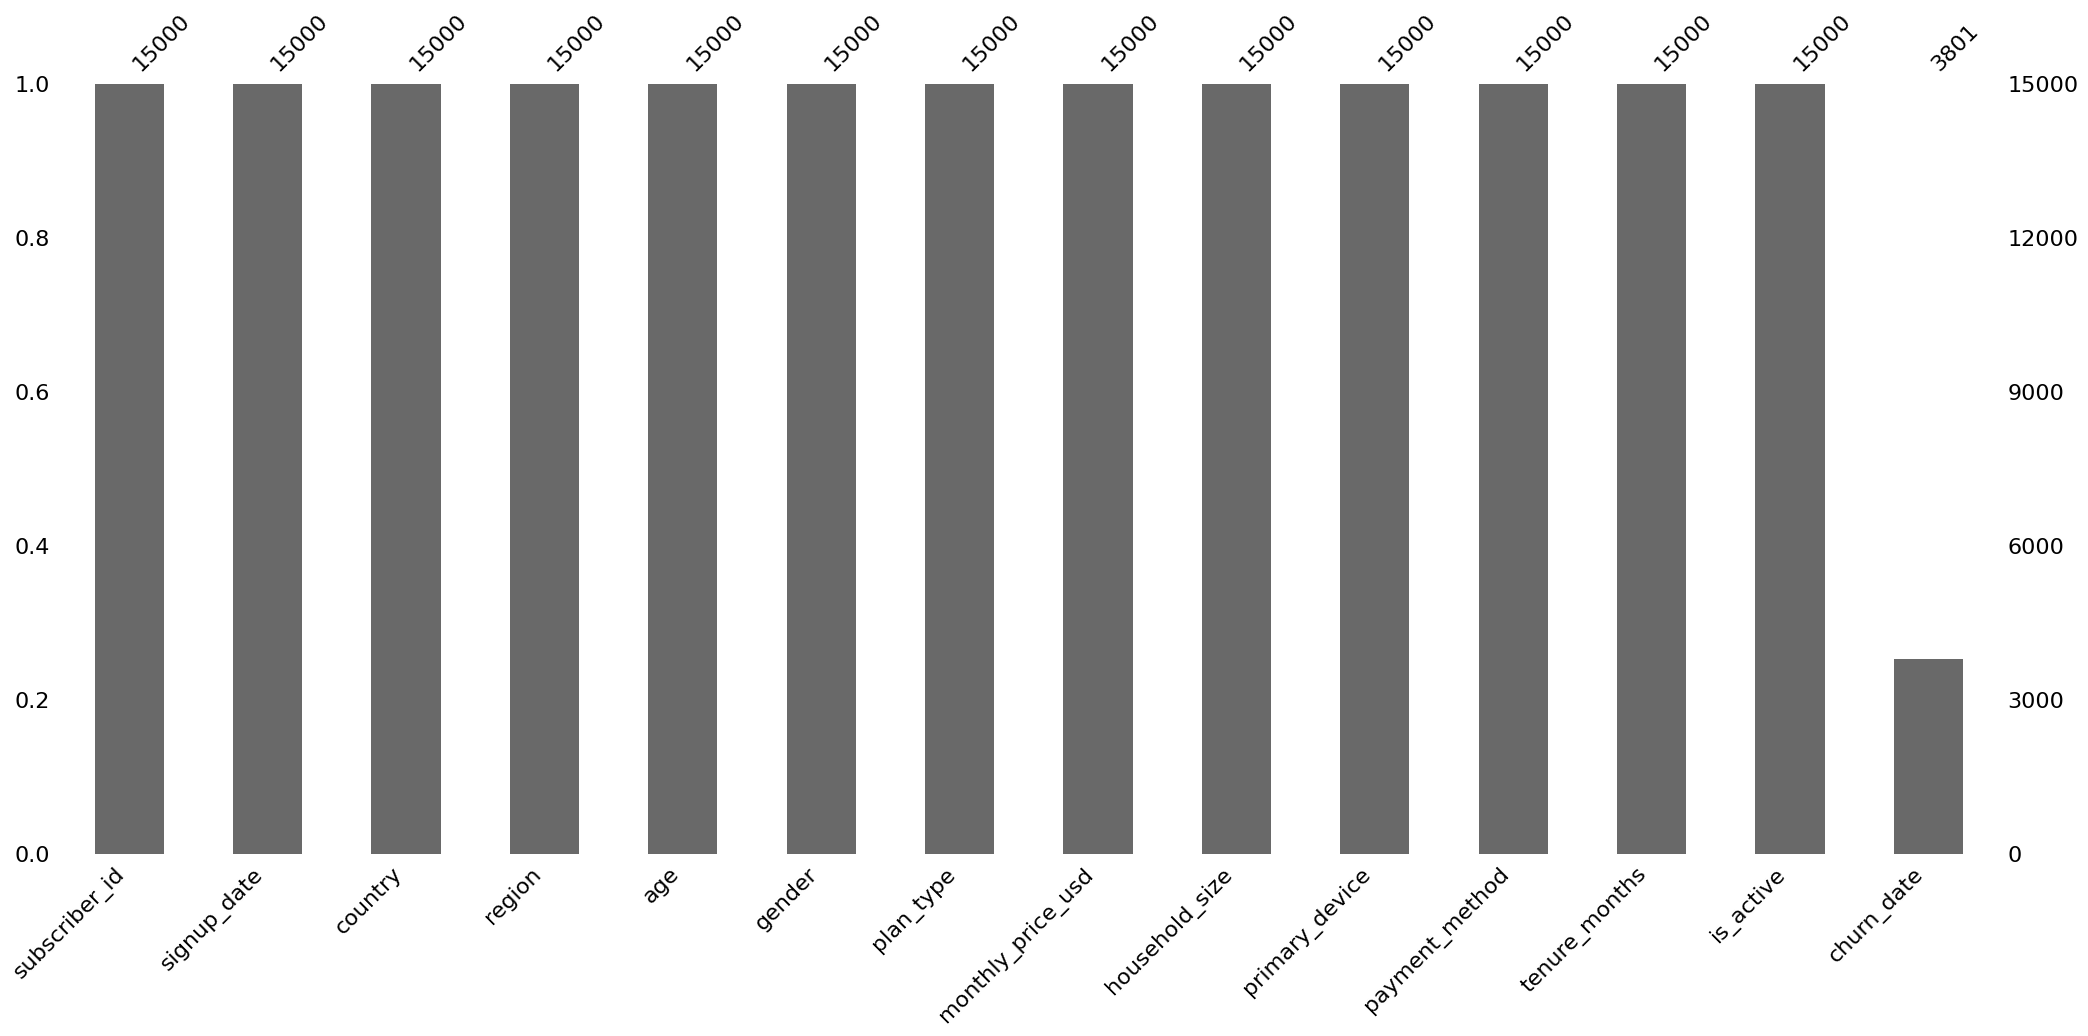

In [7]:
def null_records_analysis(table_name, table):
    print(f"{table_name} Table Null Values Analysis : ")
    print("",end = "\n")
    tatol_nulls = int(table.isnull().sum().sum())
    
    columns_list = list(table.columns)
    null_list = table.isnull().sum()
    for column, null_count in enumerate(null_list):
        if null_count > 0:
            print(f"column : '{columns_list[column]}' & Number of Nulls : {null_count}")
            print("", end = "\n")
            
    print(f"Total Subscribers : {len(table)}")
    print(f"Total Nullvalues count : {tatol_nulls}")
    print(f"Null Percentage : {round(tatol_nulls/len(table),2)}%")
    print("",end = "\n")
    print("",end = "\n")

    display(ms.bar(table))

null_records_analysis("Subscribers", subscribers_data)

### **2) Titles Table**

In [8]:
StartTime = time.time()
titles_data = pd.read_sql_query(
    """
    SELECT * 
    FROM titles;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
titles_data.sample(n = 2)

Total time taken by Query : 0.1 sec's


,title_id,title_name,type,primary_genre,country,language,release_year,date_added,maturity_rating,seasons,...,is_original,license_type,director,cast,quality_score,popularity_score,license_cost_usd,license_expiry,total_watch_hours,total_plays
4829,TTL204826,Berlin Shadows II,TV Show,Comedy,United States,English,1976,2020-04-25,PG-13,1,...,False,Co-Production,Yara Olsen,"Akira Santos, Fatima Schmidt, Liam Cohen, Amar...",71.50,0.12,2567743.00,2029-08-24,176.00,45
3848,TTL203847,Burning Madrid II,Movie,Sci-Fi,Canada,English,1986,2021-11-27,PG-13,0,...,False,Co-Production,Sven Nguyen,"Joon Nguyen, Marco Moreau, Omar Sharma, Rosa N...",77.00,18.56,282760.00,2025-12-31,1230.00,794


In [9]:
display("Shape of Titles Table : ", titles_data.shape)
print("", end = "\n")
display("columns & Associated Data Types List : ",titles_data.dtypes)
print("", end = "\n")

'Shape of Titles Table : '

(9000, 21)

'columns & Associated Data Types List : '

title_id                        object
title_name                      object
type                            object
primary_genre                   object
country                         object
language                        object
release_year                     int64
date_added              datetime64[ns]
maturity_rating                 object
seasons                          int64
content_duration_min             int64
is_original                       bool
license_type                    object
director                        object
cast                            object
quality_score                  float64
popularity_score               float64
license_cost_usd               float64
license_expiry                  object
total_watch_hours              float64
total_plays                      int64
dtype: object

In [10]:
check_duplicates("Titles", titles_data, "title_id")

Number of Duplicate Records :  0



'Duplicated Records in Titles Table(Titles[Primery Key]) : '

titles Table Null Values Analysis : 

column : 'license_expiry' & Number of Nulls : 1966

Total Subscribers : 9000
Total Nullvalues count : 1966
Null Percentage : 0.22%




<Axes: >

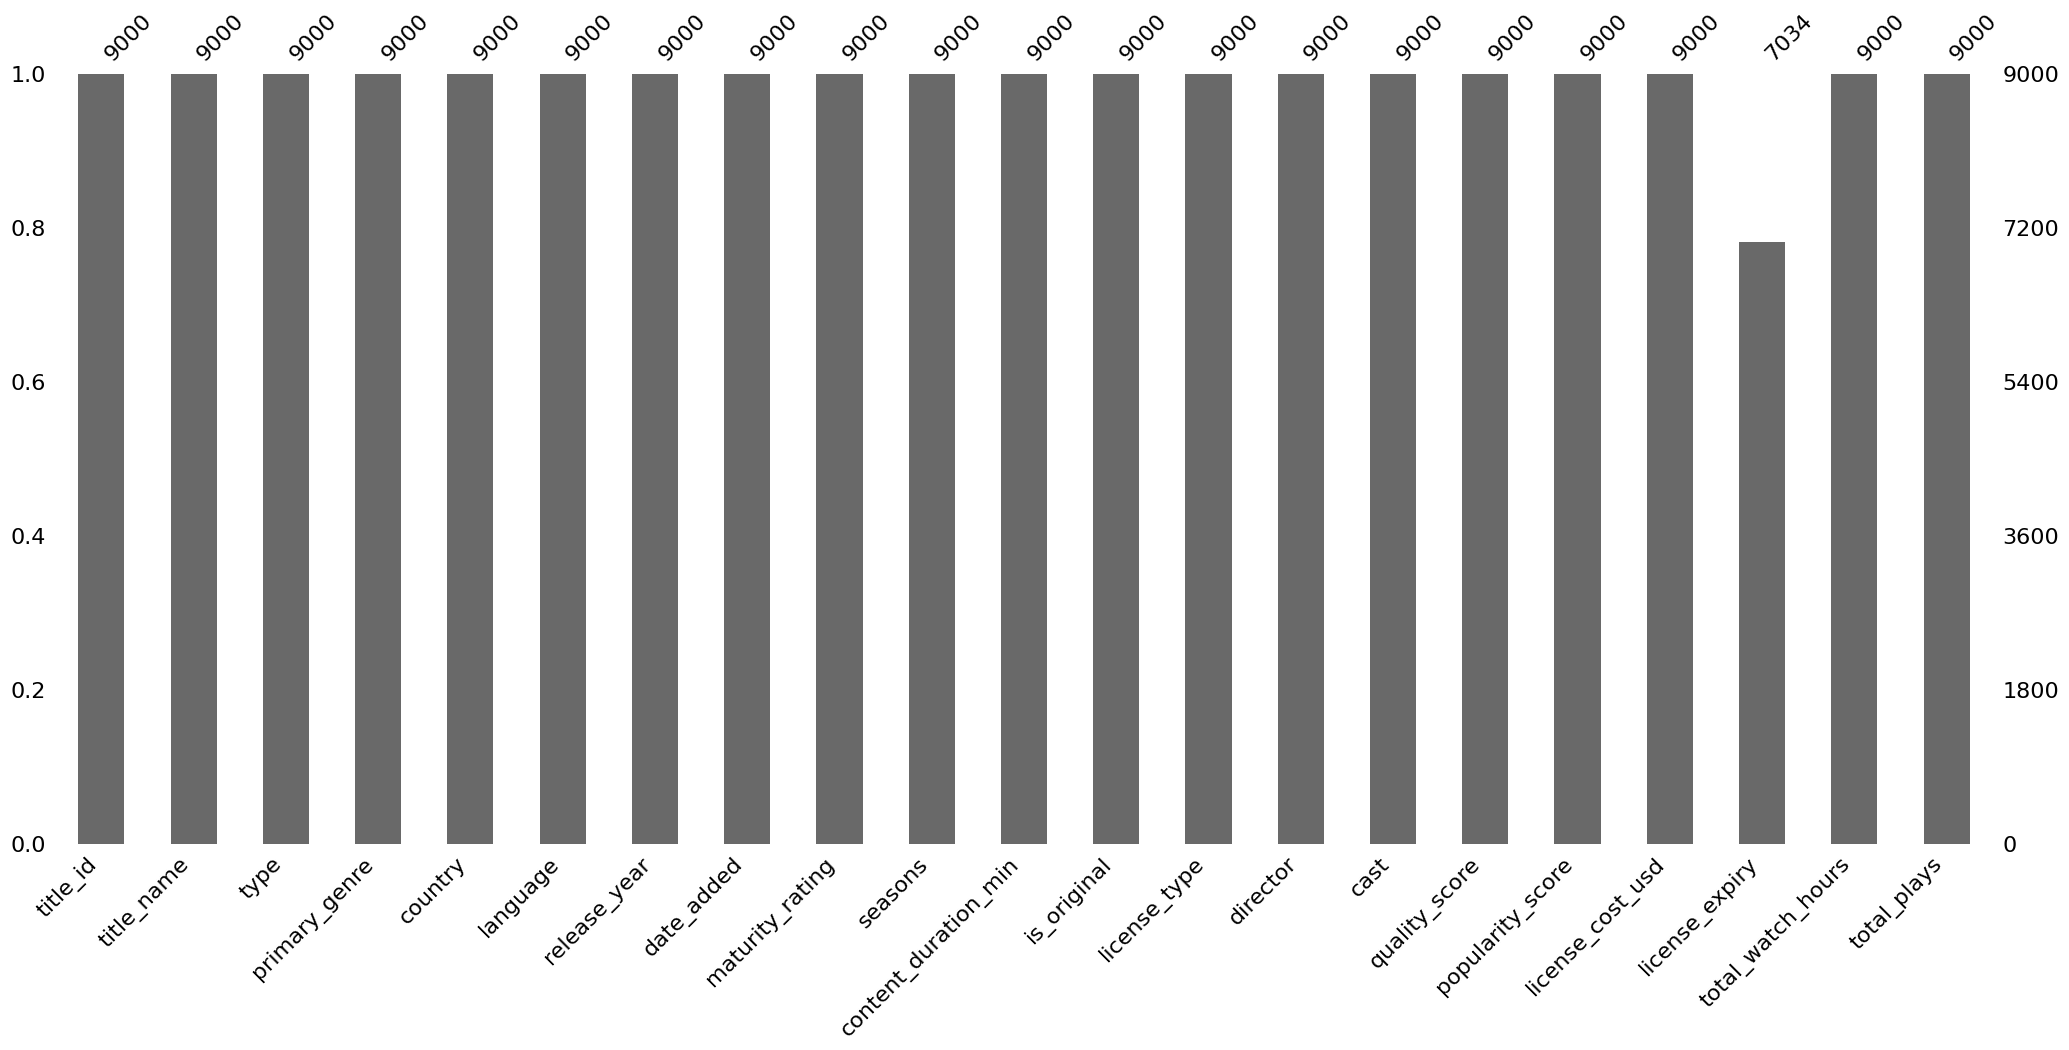

In [11]:
null_records_analysis("titles", titles_data)

In [12]:
#titles_data["date_added"] = pd.to_datetime(titles_data["date_added"])
#titles_data.to_sql(name='titles', con=engine, if_exists='replace', index=False)

### **3) Ratings Table**

In [14]:
StartTime = time.time()
ratings_data = pd.read_sql_query(
    """
    SELECT * 
    FROM ratings;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
ratings_data.sample(n = 4)

Total time taken by Query : 0.42 sec's


,rating_id,subscriber_id,title_id,rating,rating_date
10726,10727,SUB102932,TTL208882,2,2019-01-25
32014,32015,SUB112097,TTL202834,2,2023-10-20
73244,73245,SUB100391,TTL201059,1,2024-09-14
94988,94989,SUB106688,TTL205753,4,2026-05-24


In [15]:
display("Total Size of the Table : ", ratings_data.size)
print("", end = "\n")
display("Shape of ratings Table : ", ratings_data.shape)
print("", end = "\n")
display("columns & Associated Data Types List : ",ratings_data.dtypes)
print("", end = "\n")

'Total Size of the Table : '

650000

'Shape of ratings Table : '

(130000, 5)

'columns & Associated Data Types List : '

rating_id         int64
subscriber_id    object
title_id         object
rating            int64
rating_date      object
dtype: object

In [16]:
check_duplicates("Ratings", ratings_data, "rating_id")

Number of Duplicate Records :  0



'Duplicated Records in Ratings Table(Ratings[Primery Key]) : '

In [17]:
query = """
SELECT table_name
FROM information_schema.tables
WHERE table_schema = 'public'
ORDER BY table_name;
"""

pd.read_sql(query, engine)

,table_name
0,ratings
1,reviews
2,subscribers
3,titles
4,watch_history
5,watchlist


Ratings Table Null Values Analysis : 

Total Subscribers : 130000
Total Nullvalues count : 0
Null Percentage : 0.0%




<Axes: >

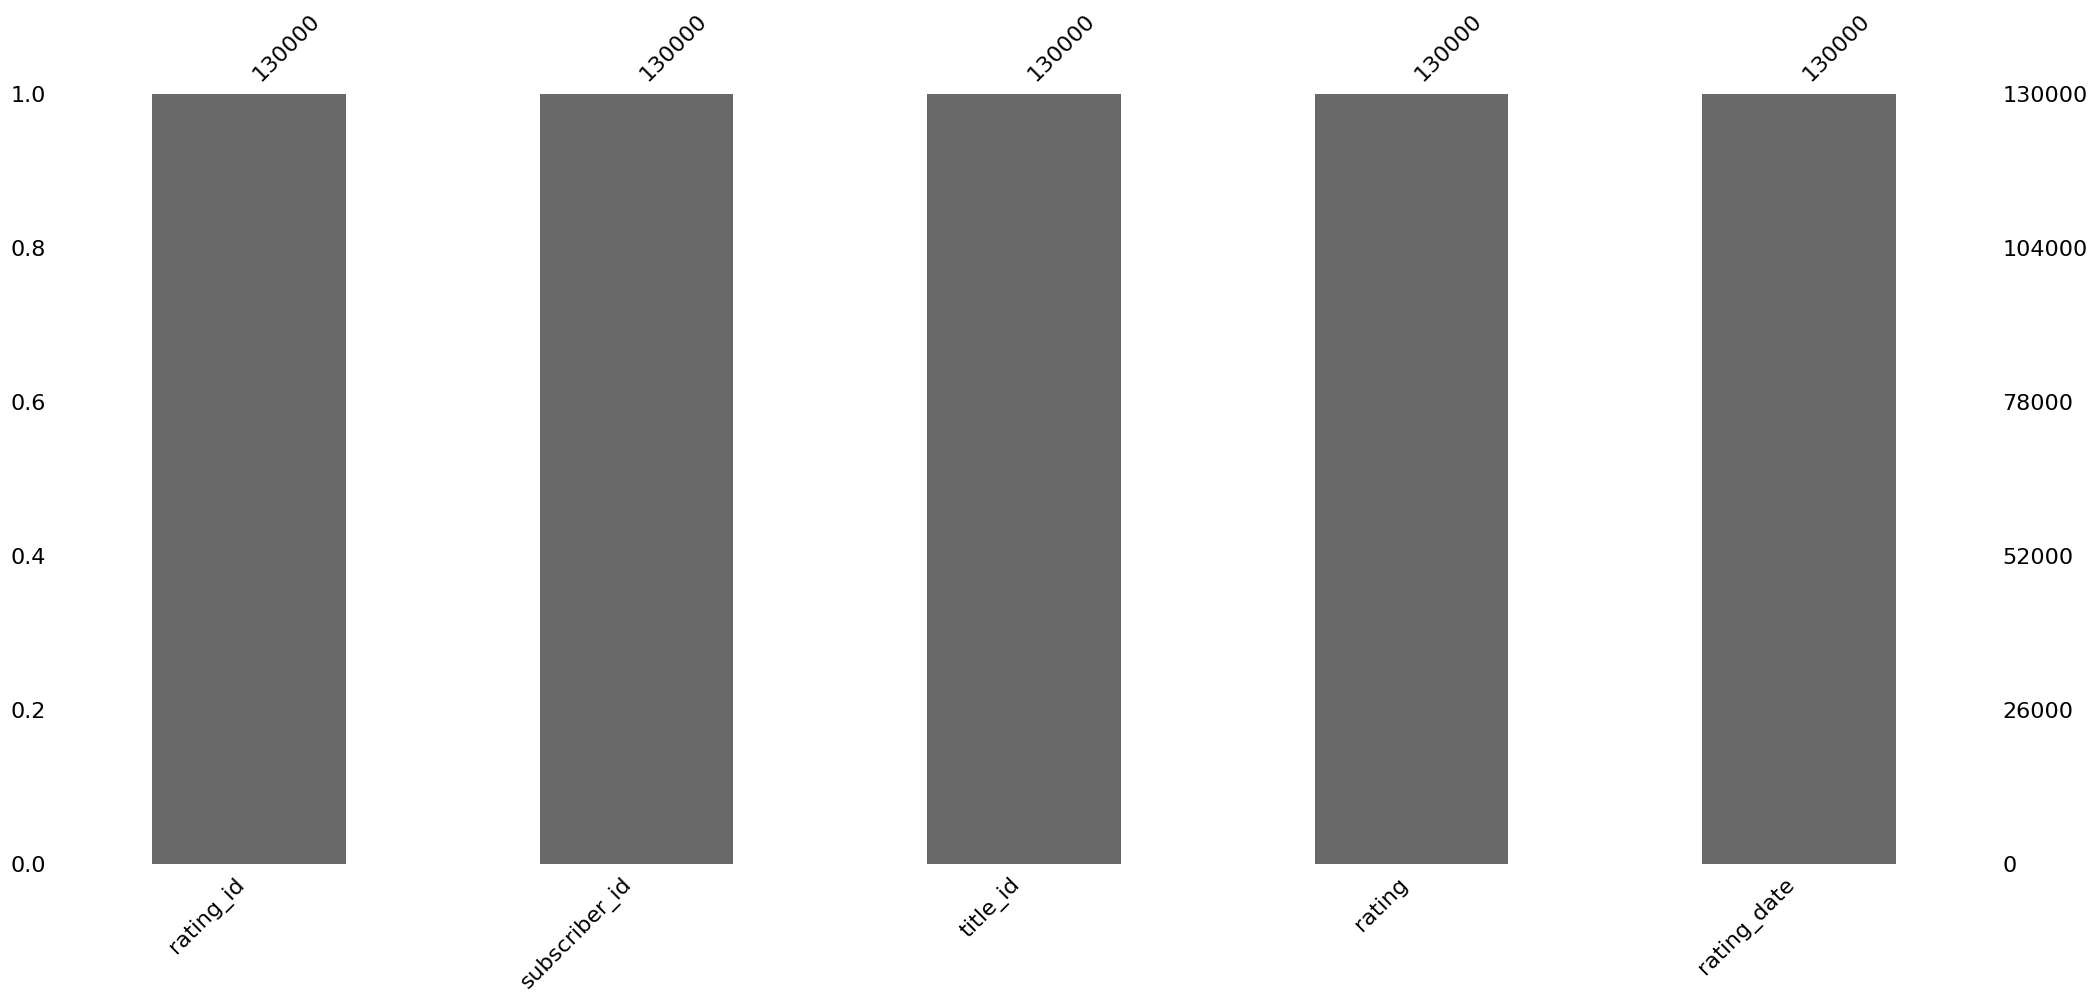

In [18]:
null_records_analysis("Ratings", ratings_data)

In [19]:
ratings_data["rating_date"] = pd.to_datetime(ratings_data["rating_date"])
ratings_data.to_sql(name='ratings', con=engine, if_exists='replace', index=False)

1000

### **4) Reviews Table**

In [20]:
StartTime = time.time()
reviews_data = pd.read_sql_query(
    """
    SELECT * 
    FROM reviews;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
reviews_data.sample(n = 4)

Total time taken by Query : 0.73 sec's


,review_id,subscriber_id,title_id,review_text,sentiment,helpful_votes,review_date
66530,66531,SUB101218,TTL202661,Couldn't stop watching — binged it in a weekend.,Positive,9,2025-11-03
23291,23292,SUB104607,TTL205898,Slow and hard to finish.,Negative,3,2018-08-31
94529,94530,SUB112274,TTL202504,Disappointing given the hype.,Negative,5,2025-12-25
60795,60796,SUB105577,TTL206775,One of the best things I've streamed this year.,Positive,4,2026-05-29


In [21]:
reviews_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110000 entries, 0 to 109999
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   review_id      110000 non-null  int64         
 1   subscriber_id  110000 non-null  object        
 2   title_id       110000 non-null  object        
 3   review_text    110000 non-null  object        
 4   sentiment      110000 non-null  object        
 5   helpful_votes  110000 non-null  int64         
 6   review_date    110000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 5.9+ MB


In [22]:
check_duplicates("Ratings", reviews_data, "review_id")

Number of Duplicate Records :  0



'Duplicated Records in Ratings Table(Ratings[Primery Key]) : '

Ratings Table Null Values Analysis : 

Total Subscribers : 110000
Total Nullvalues count : 0
Null Percentage : 0.0%




<Axes: >

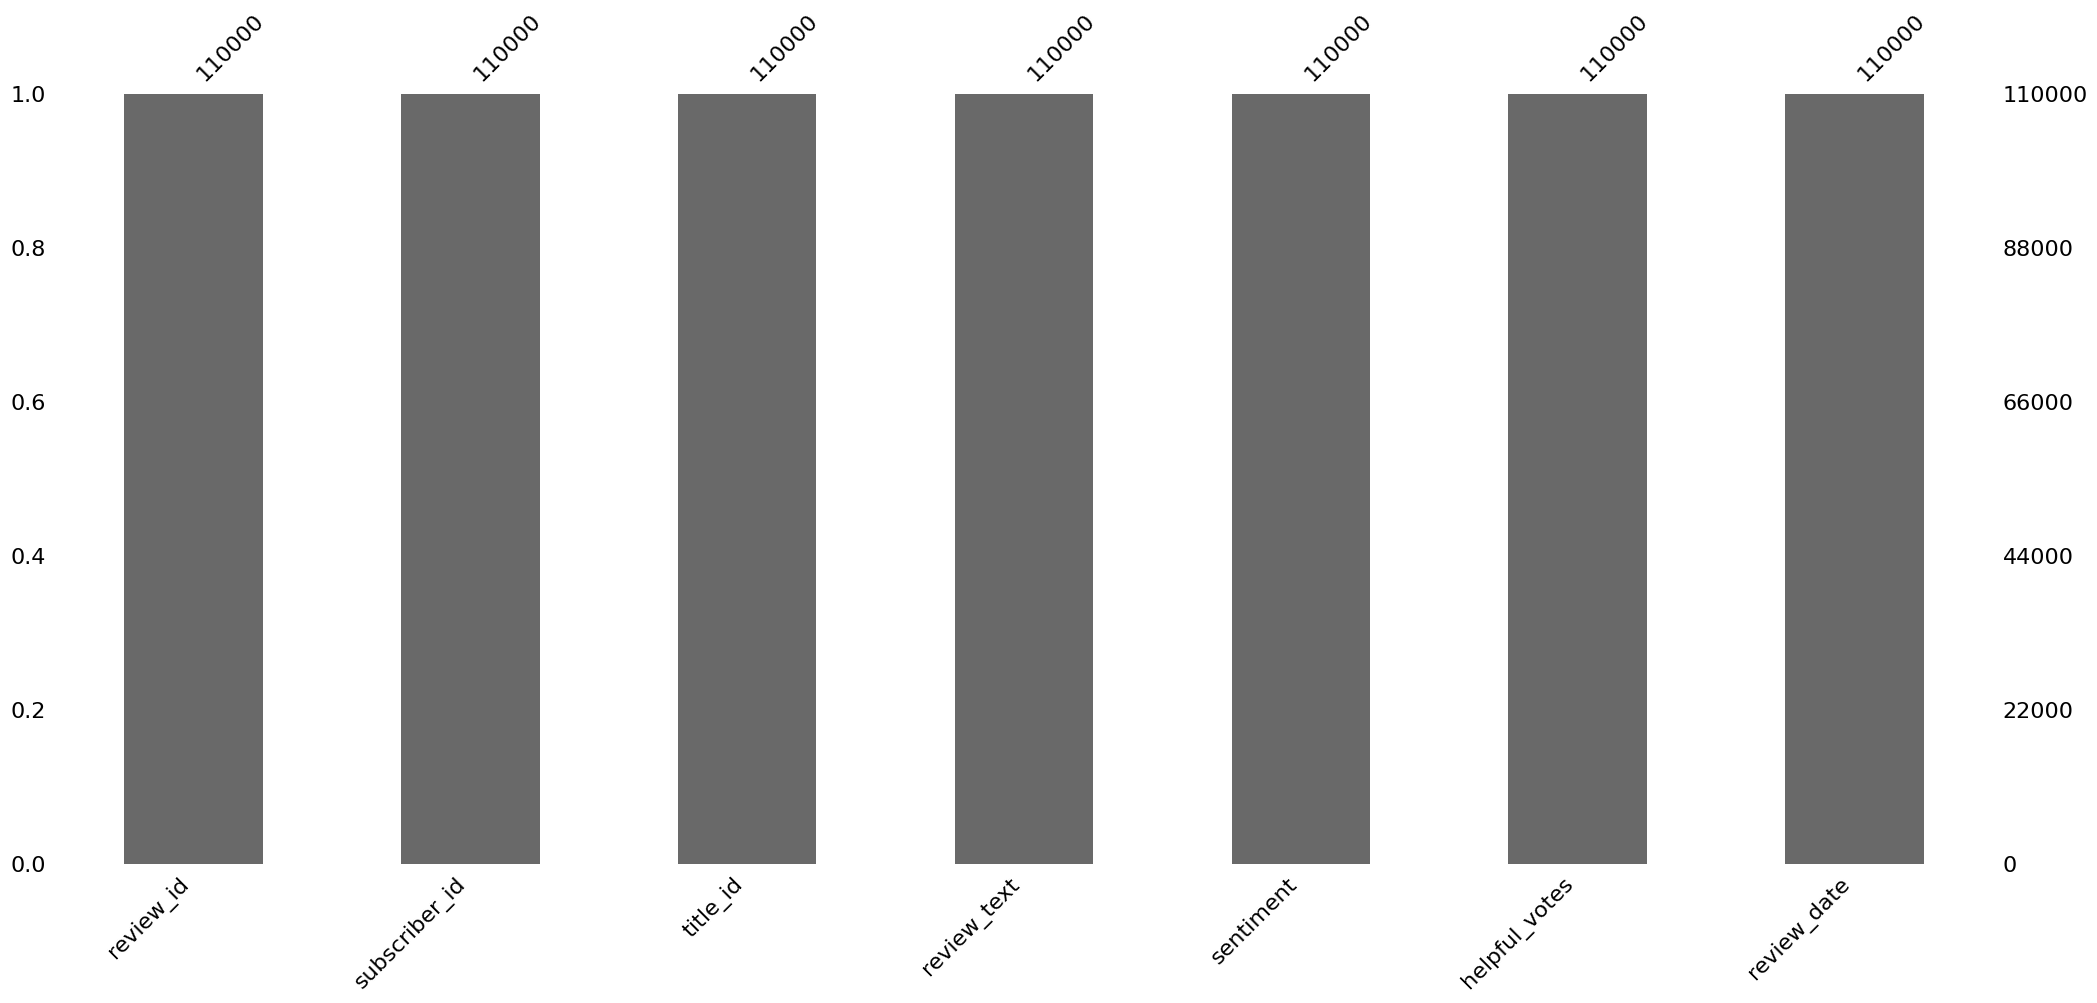

In [23]:
null_records_analysis("Ratings", reviews_data)

In [24]:
reviews_data["review_date"] = pd.to_datetime(reviews_data["review_date"])
reviews_data.to_sql(name='reviews', con=engine, if_exists='replace', index=False)

1000

### **5) Watch History Table**

In [25]:
StartTime = time.time()
watch_history_data = pd.read_sql_query(
    """
    SELECT * 
    FROM watch_history;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
watch_history_data.sample(n = 5)

Total time taken by Query : 12.01 sec's


,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,watch_duration_hourse
379289,379172,SUB107935,TTL202916,2026-01-10,Mobile,South Asia,123,119.20,96.90,True,1.99
532528,532477,SUB111668,TTL204450,2024-11-04,Tablet,Europe,1008,417.80,41.40,False,6.96
79020,78760,SUB110663,TTL205745,2025-07-03,Mobile,Europe,98,83.00,84.70,False,1.38
441675,441592,SUB109091,TTL200595,2026-04-24,Mobile,East Asia,83,28.60,34.50,False,0.48
605901,605887,SUB105114,TTL202356,2026-02-09,Smart TV,North America,195,116.80,59.90,False,1.95


In [26]:
watch_history_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   watch_id               650000 non-null  int64         
 1   subscriber_id          650000 non-null  object        
 2   title_id               650000 non-null  object        
 3   watch_date             650000 non-null  datetime64[ns]
 4   device                 650000 non-null  object        
 5   region                 650000 non-null  object        
 6   content_duration_min   650000 non-null  int64         
 7   watch_duration_min     650000 non-null  float64       
 8   completion_pct         650000 non-null  float64       
 9   completed              650000 non-null  bool          
 10  watch_duration_hourse  650000 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 50.2+ MB


In [27]:
check_duplicates("Watch History", watch_history_data, "watch_id")

Number of Duplicate Records :  0



'Duplicated Records in Watch History Table(Watch History[Primery Key]) : '

In [28]:
display("Total Number of Outliers in Watch Duration : ", len(watch_history_data[watch_history_data["content_duration_min"] < watch_history_data["watch_duration_min"]]))
print("",end = "\n")
display("Outlier Records in Watch History(watch_duration_min) : ")
print("",end = "\n")
watch_history_data[watch_history_data["content_duration_min"] < watch_history_data["watch_duration_min"]]

'Total Number of Outliers in Watch Duration : '

0

'Outlier Records in Watch History(watch_duration_min) : '

,watch_id,subscriber_id,title_id,watch_date,device,region,content_duration_min,watch_duration_min,completion_pct,completed,watch_duration_hourse


### **6) Watchlist Table**

In [29]:
StartTime = time.time()
watchlist_data = pd.read_sql_query(
    """
    SELECT * 
    FROM watchlist;
    
    """,
    con = engine
)
EndTime = time.time()
print(f"Total time taken by Query : {round(EndTime - StartTime, 2)} sec's")
watchlist_data.sample(n = 5)

Total time taken by Query : 0.55 sec's


,watchlist_id,subscriber_id,title_id,added_date,watched
230,231,SUB107696,TTL201612,2019-12-15,False
51956,51957,SUB106198,TTL202672,2024-11-26,True
6070,6071,SUB105465,TTL205508,2026-03-29,False
10770,10771,SUB101528,TTL203259,2021-11-13,True
18907,18908,SUB105386,TTL206337,2022-06-02,False


In [30]:
display("Total Size of the Table : ", watchlist_data.size)
print("", end = "\n")
display("Shape of ratings Table : ", watchlist_data.shape)
print("", end = "\n")
display("columns & Associated Data Types List : ", watchlist_data.dtypes)
print("", end = "\n")

'Total Size of the Table : '

325000

'Shape of ratings Table : '

(65000, 5)

'columns & Associated Data Types List : '

watchlist_id      int64
subscriber_id    object
title_id         object
added_date       object
watched            bool
dtype: object

In [31]:
check_duplicates("Watch List", watchlist_data, "watchlist_id")

Number of Duplicate Records :  0



'Duplicated Records in Watch List Table(Watch List[Primery Key]) : '

Watch List Table Null Values Analysis : 

Total Subscribers : 65000
Total Nullvalues count : 0
Null Percentage : 0.0%




<Axes: >

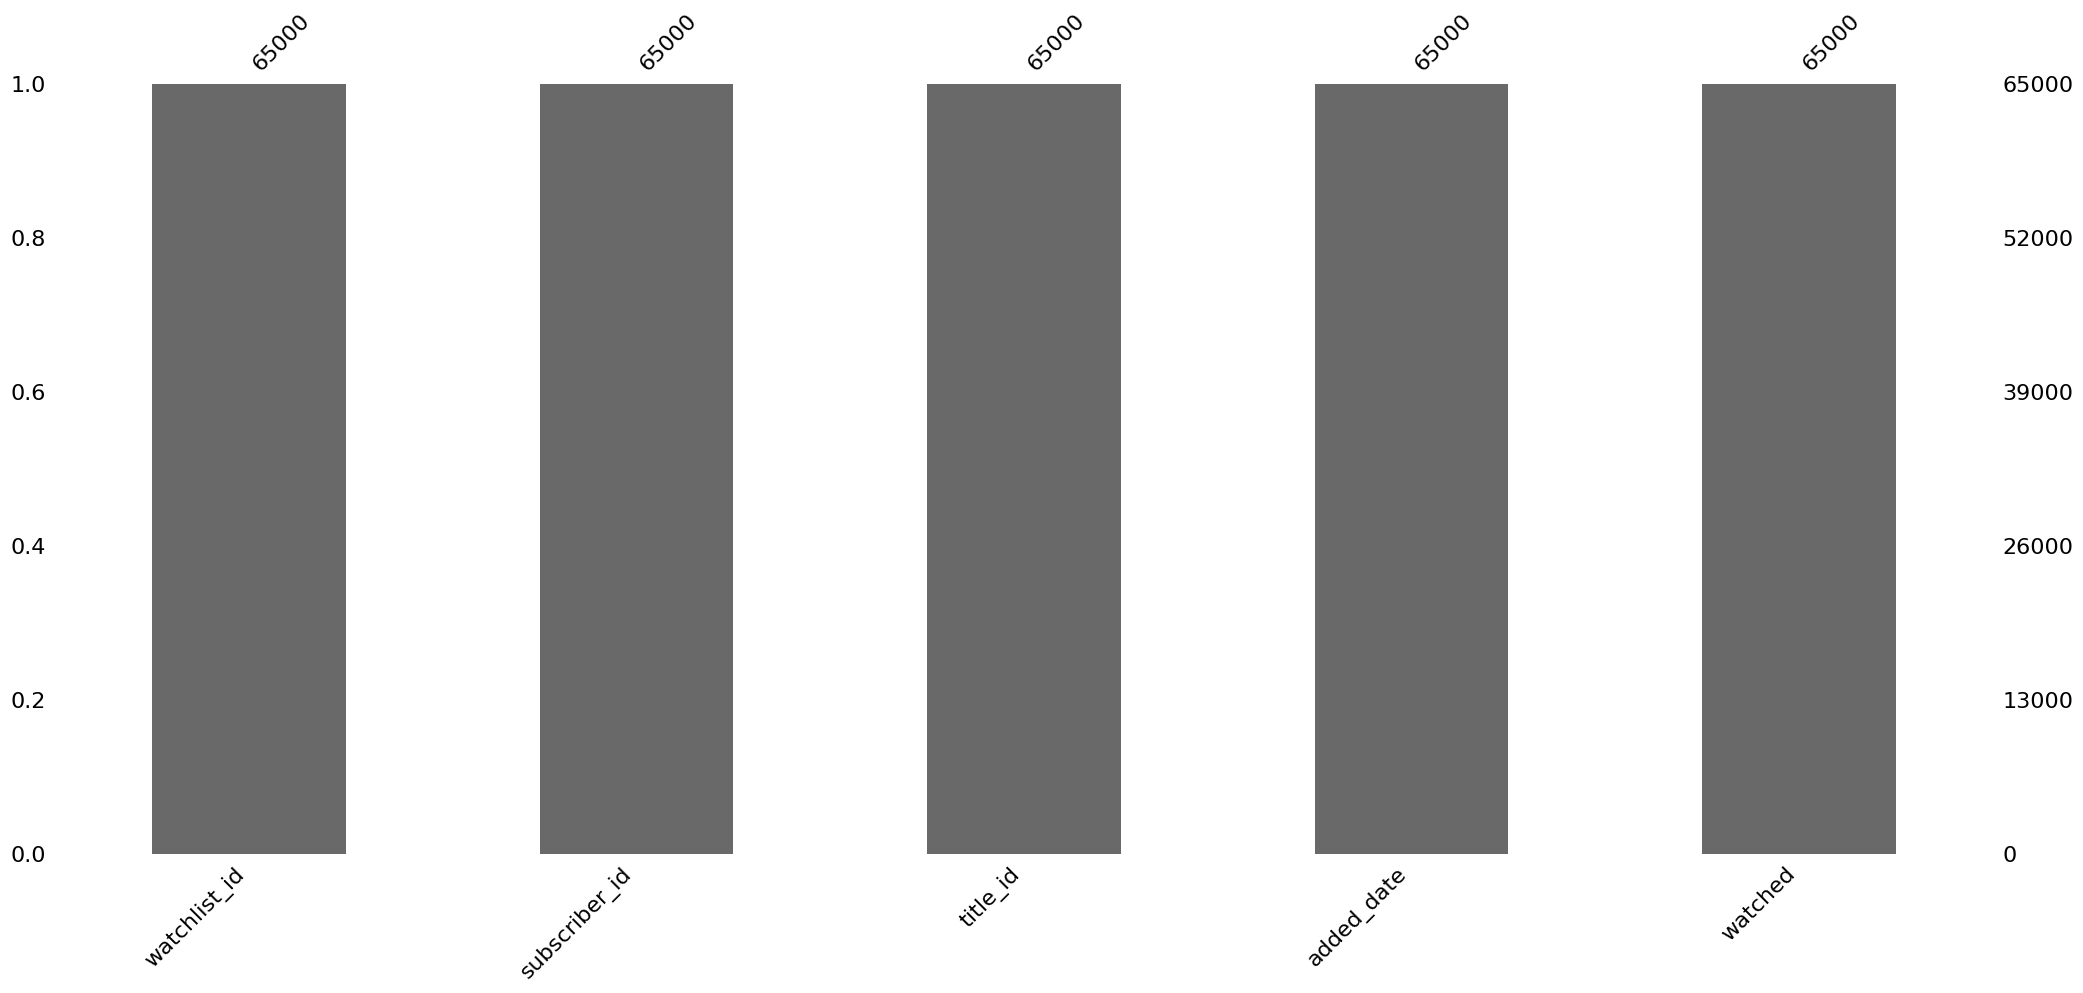

In [32]:
null_records_analysis("Watch List", watchlist_data)

## **3) Data Quality or Validation Checks**

In [33]:
subscribers_data.columns

Index(['subscriber_id', 'signup_date', 'country', 'region', 'age', 'gender',
       'plan_type', 'monthly_price_usd', 'household_size', 'primary_device',
       'payment_method', 'tenure_months', 'is_active', 'churn_date'],
      dtype='object')

In [34]:
copy_subscribers_data = subscribers_data.copy()
copy_subscribers_data.dropna(inplace = True)
copy_subscribers_data["churn_date"] = pd.to_datetime(copy_subscribers_data["churn_date"])
display("Valid Records : ")
print("", end = "\n")
display(copy_subscribers_data[copy_subscribers_data["signup_date"] < copy_subscribers_data["churn_date"]].shape)
print("", end = "\n")
display(copy_subscribers_data[copy_subscribers_data["signup_date"] < copy_subscribers_data["churn_date"]].head(5))
print("", end = "\n")
display("Invalid Records : ")
print("", end = "\n")
display(copy_subscribers_data[copy_subscribers_data["signup_date"] > copy_subscribers_data["churn_date"]].shape)
print("", end = "\n")
display(copy_subscribers_data[copy_subscribers_data["signup_date"] > copy_subscribers_data["churn_date"]])

'Valid Records : '

(3801, 14)

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
1,SUB100001,2020-02-05,United Kingdom,Europe,48,Male,Basic with Ads,6.99,1,Smart TV,Credit Card,76,False,2022-12-08
4,SUB100004,2020-04-12,United States,North America,36,Female,Basic with Ads,6.99,1,Mobile,Credit Card,74,False,2021-12-15
6,SUB100006,2023-08-27,France,Europe,32,Male,Basic with Ads,6.99,1,Game Console,Debit Card,33,False,2024-10-19
9,SUB100009,2019-07-28,United Kingdom,Europe,25,Male,Basic with Ads,6.99,1,Tablet,Credit Card,83,False,2020-07-22
12,SUB100012,2026-04-06,Brazil,Latin America,33,Female,Premium,22.99,3,Mobile,Credit Card,1,False,2026-05-08


'Invalid Records : '

(0, 14)

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date


In [35]:
subscribers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   subscriber_id      15000 non-null  object        
 1   signup_date        15000 non-null  datetime64[ns]
 2   country            15000 non-null  object        
 3   region             15000 non-null  object        
 4   age                15000 non-null  int64         
 5   gender             15000 non-null  object        
 6   plan_type          15000 non-null  object        
 7   monthly_price_usd  15000 non-null  float64       
 8   household_size     15000 non-null  int64         
 9   primary_device     15000 non-null  object        
 10  payment_method     15000 non-null  object        
 11  tenure_months      15000 non-null  int64         
 12  is_active          15000 non-null  bool          
 13  churn_date         3801 non-null   object        
dtypes: boo

In [36]:
active_subscribers = subscribers_data[subscribers_data["is_active"] == True]
display("Total Active Subscribers : ", len(active_subscribers))
print("", end = "\n")
display("Invalid Records : ")
print("", end = "\n")
display(active_subscribers[active_subscribers["churn_date"].isnull()].shape)
print("", end = "\n")
display(active_subscribers[active_subscribers["churn_date"].isnull()].head(5))
print("", end = "\n")
display("Invalid Records : ")
print("", end = "\n")
display(active_subscribers[active_subscribers["churn_date"].notnull()].shape)
print("", end = "\n")
active_subscribers[active_subscribers["churn_date"].notnull()]

'Total Active Subscribers : '

11199

'Invalid Records : '

(11199, 14)

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
0,SUB100000,2023-01-09,France,Europe,22,Female,Basic with Ads,6.99,1,Mobile,Credit Card,41,True,None
2,SUB100002,2022-04-15,Italy,Europe,35,Male,Standard,15.49,2,Streaming Stick,Gift Card,50,True,None
3,SUB100003,2024-10-10,Spain,Europe,49,Female,Basic with Ads,6.99,1,Laptop,Credit Card,19,True,None
5,SUB100005,2020-10-11,Thailand,Southeast Asia,48,Female,Standard,15.49,1,Laptop,Debit Card,68,True,None
7,SUB100007,2025-08-13,Germany,Europe,56,Female,Standard,15.49,1,Smart TV,Credit Card,9,True,None


'Invalid Records : '

(0, 14)

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date


In [37]:
watch_history_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650000 entries, 0 to 649999
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   watch_id               650000 non-null  int64         
 1   subscriber_id          650000 non-null  object        
 2   title_id               650000 non-null  object        
 3   watch_date             650000 non-null  datetime64[ns]
 4   device                 650000 non-null  object        
 5   region                 650000 non-null  object        
 6   content_duration_min   650000 non-null  int64         
 7   watch_duration_min     650000 non-null  float64       
 8   completion_pct         650000 non-null  float64       
 9   completed              650000 non-null  bool          
 10  watch_duration_hourse  650000 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 50.2+ MB


In [38]:
test_completion_pct = round((watch_history_data["watch_duration_min"] / watch_history_data["content_duration_min"]) * 100.0,2)
actual_completion_pct = watch_history_data["completion_pct"]

In [39]:
test_completion_pct[:10]

0   97.90
1   57.29
2   12.31
3   94.16
4   94.36
5   87.56
6   53.26
7   78.16
8   98.70
9   93.36
dtype: float64

In [40]:
actual_completion_pct[:10]

0   97.90
1   57.30
2   12.30
3   94.20
4   94.30
5   87.60
6   53.30
7   78.10
8   98.80
9   93.40
Name: completion_pct, dtype: float64

In [41]:
valid_items = list(reviews_data["sentiment"].unique())
valid_items

['Positive', 'Negative', 'Neutral']

In [42]:
watchlist_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65000 entries, 0 to 64999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   watchlist_id   65000 non-null  int64 
 1   subscriber_id  65000 non-null  object
 2   title_id       65000 non-null  object
 3   added_date     65000 non-null  object
 4   watched        65000 non-null  bool  
dtypes: bool(1), int64(1), object(3)
memory usage: 2.0+ MB


In [43]:
StartTime = time.time()
valid_checklist = []
invalid_checklist = []
for idx, subscriber_id in enumerate(watchlist_data["subscriber_id"]):
    if subscriber_id in subscribers_data["subscriber_id"].values:
        valid_checklist.append("True")
    else:
        invalid_checklist.append("False")
display("Shape of watchlist Table", watchlist_data.shape)
print("", end = "\n")
display("Total valid Records : ", len(valid_checklist))
print("", end = "\n")
display("Total invalid Records : ", len(invalid_checklist))
print("", end = "\n")
EndTime = time.time()
print(f"Total time taken to excute : {round(EndTime - StartTime, 2)} sec's")

'Shape of watchlist Table'

(65000, 5)

'Total valid Records : '

65000

'Total invalid Records : '

0


Total time taken to excute : 55.74 sec's


In [44]:
subscribers_data.head()

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
0,SUB100000,2023-01-09,France,Europe,22,Female,Basic with Ads,6.99,1,Mobile,Credit Card,41,True,None
1,SUB100001,2020-02-05,United Kingdom,Europe,48,Male,Basic with Ads,6.99,1,Smart TV,Credit Card,76,False,2022-12-08
2,SUB100002,2022-04-15,Italy,Europe,35,Male,Standard,15.49,2,Streaming Stick,Gift Card,50,True,None
3,SUB100003,2024-10-10,Spain,Europe,49,Female,Basic with Ads,6.99,1,Laptop,Credit Card,19,True,None
4,SUB100004,2020-04-12,United States,North America,36,Female,Basic with Ads,6.99,1,Mobile,Credit Card,74,False,2021-12-15


In [45]:
subscribers_data.describe()

,signup_date,age,monthly_price_usd,household_size,tenure_months
count,15000,15000.00,15000.00,15000.00,15000.00
mean,2022-09-06 21:09:01.440000,35.62,15.18,1.66,44.97
min,2016-01-13 00:00:00,13.00,6.99,1.00,1.00
25%,2020-10-17 00:00:00,27.00,6.99,1.00,18.00
50%,2023-01-25 00:00:00,35.00,15.49,1.00,40.00
75%,2024-11-24 00:00:00,44.00,22.99,2.00,68.00
max,2026-05-31 00:00:00,85.00,22.99,4.00,126.00
std,NaN,12.53,6.17,0.91,31.39


In [46]:
threshold_value = 5
short_tenure_subscribers = subscribers_data[subscribers_data["tenure_months"] <= threshold_value]
still_active_subscribers = short_tenure_subscribers[short_tenure_subscribers["is_active"] == True]
display("Total Active Subscribers with short Tenure Months : ", len(still_active_subscribers))
print("", end = "\n")
display("Active Subscribers with short Tenure Months : ")
print("", end = "\n")
display(still_active_subscribers.head())

'Total Active Subscribers with short Tenure Months : '

993

'Active Subscribers with short Tenure Months : '

,subscriber_id,signup_date,country,region,age,gender,plan_type,monthly_price_usd,household_size,primary_device,payment_method,tenure_months,is_active,churn_date
13,SUB100013,2026-01-30,Canada,North America,37,Male,Basic with Ads,6.99,1,Mobile,Credit Card,4,True,None
30,SUB100030,2026-01-31,France,Europe,21,Male,Premium,22.99,1,Game Console,Credit Card,4,True,None
66,SUB100066,2026-05-18,Japan,East Asia,25,Male,Basic with Ads,6.99,1,Smart TV,Mobile Wallet,1,True,None
87,SUB100087,2026-03-29,South Korea,East Asia,13,Male,Standard,15.49,2,Tablet,Credit Card,2,True,None
91,SUB100091,2025-12-06,Spain,Europe,35,Female,Basic with Ads,6.99,1,Smart TV,Debit Card,5,True,None


## **4) Basic Sweetviz Report**

In [47]:
ROOT_DIR

WindowsPath('C:/Users/KISHORE/OneDrive/Pictures/Documents/internmo/StreamFlix-Content-Analytics')

In [48]:
os.chdir(ROOT_DIR/Reports)

tables_list = [subscribers_data, titles_data, reviews_data, ratings_data, watchlist_data, watch_history_data]
table_names = ["Subscribers", "Titles", "Reviews", "Ratings", "Watchlist", "WatchHistory"]
for idx,table in enumerate(tables_list):
    report = sv.analyze(table)
    report.show_html(table_names[idx] + "_dataset_sv_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report Subscribers_dataset_sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |                                             | [  0%]   00:00 ->…

Report Titles_dataset_sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |                                             | [  0%]   00:00 ->…

...

Report Ratings_dataset_sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |                                             | [  0%]   00:00 ->…

Report Watchlist_dataset_sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


                                             |                                             | [  0%]   00:00 ->…

Report WatchHistory_dataset_sv_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
